In [60]:
import numpy as np
import pandas as pd
from pathlib import Path
from common.consts import long_to_short

def read_colvar_with_fields(path: Path) -> pd.DataFrame:
    with path.open() as f:
        header = next(line for line in f if line.startswith("#!"))
    parts = header.strip().split()
    names = parts[2:]
    return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

def hlda(A: np.ndarray, B: np.ndarray, desc_cols: list[str], ridge: float = 1e-8):

    mu_A, mu_B = A.mean(0), B.mean(0)
    SA, SB = np.cov(A, rowvar=False), np.cov(B, rowvar=False)

    d = SA.shape[0]
    # ridge stabilization
    SA = SA + ridge * np.eye(d)
    SB = SB + ridge * np.eye(d)

    # combined precision (use pinv for numerical safety)
    PA = np.linalg.pinv(SA)
    PB = np.linalg.pinv(SB)
    P  = PA + PB

    delta = (mu_A - mu_B)
    W = P @ delta
    nrm = np.linalg.norm(W)
    W_norm = W / nrm if nrm > 0 else np.zeros_like(W)

    # HLDA separation scalar (Rayleigh quotient)
    lam = float(delta @ (P @ delta))
    return pd.Series(W_norm, index=desc_cols), lam


wt = "chignolin"
rmsd_threshold = 0.1
wt_path = Path(f"../data/{wt}/output/run_000/COLVAR_000")
df_wt = read_colvar_with_fields(wt_path)

# select only dXX descriptors (single-digit indices assumed)
descriptors = [c for c in df_wt.columns if c.startswith("d")]
df_wt_filt = df_wt[df_wt["rmsd"] < rmsd_threshold]
A = df_wt_filt[descriptors].to_numpy()

weights_rows = {}
lambda_scores = {}

for protein in long_to_short.keys():
    if protein == wt:
        continue  # skip WT vs WT (would give zero separation)
    path = Path(f"../data/{protein}/output/run_000/COLVAR_000")
    df_mut = read_colvar_with_fields(path)
    df_mut_filt = df_mut[df_mut["rmsd"] < rmsd_threshold]
    B = df_mut_filt[descriptors].to_numpy()

    W_norm, lam = hlda(A, B, descriptors, ridge=1e-8)
    short = long_to_short[protein]
    weights_rows[short] = W_norm
    lambda_scores[short] = lam

weights_df = pd.DataFrame.from_dict(weights_rows, orient="index")
eigenvalue_series = pd.Series(lambda_scores, name="hlda_separation")

print("HLDA weights (first rows):")
print(weights_df.head())
print("\nHLDA separation (λ) per mutant (top 10):")
print(eigenvalue_series.sort_values(ascending=False).head(10))


HLDA weights (first rows):
          d03       d04       d05       d06       d07       d08       d09  \
D2A  0.073369  0.053746 -0.024586 -0.034557 -0.083097  0.074743  0.004998   
D2C  0.181295  0.137583 -0.197602 -0.056931 -0.127609  0.147906  0.054361   
D2M -0.058809  0.029269  0.031192 -0.037732  0.039909  0.035159 -0.033869   
D2N -0.094927  0.279108 -0.071612  0.086546 -0.253412  0.207699 -0.044082   
D2R -0.149204  0.125550 -0.024765  0.174614 -0.196918  0.014712  0.022918   

          d14       d15       d16  ...       d36       d37       d38  \
D2A -0.152973  0.070604 -0.007282  ...  0.048969  0.006686 -0.121872   
D2C -0.290711  0.201669  0.080018  ...  0.116443 -0.126857  0.060682   
D2M -0.133372 -0.009864  0.185668  ...  0.022396 -0.069019  0.055904   
D2N -0.335854  0.041783  0.014472  ...  0.162481 -0.401311  0.194594   
D2R -0.153004  0.021680  0.191515  ... -0.007056 -0.208014  0.223175   

          d39       d47       d48       d49       d58       d59       d69  
D

In [61]:
with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)
    
thresholds = np.array(list(all_mfpt['chignolin'].keys()))
df = collect_df(True, all_mfpt, thresholds[1])

mfpt = df['mfpt']
y = np.log(mfpt['WT'] / mfpt.drop(labels=["WT"], errors="ignore"))

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# -------- Config --------
base_dir = Path("../data/traj")
f_filename = "COLVAR_CV_F_full"
uf_filename = "COLVAR_CV_UF_full_old"
sample_n = 800_000
ridge = 1e-8
n_bins = 200

# New threshold grids:
tF_grid = np.linspace(0.1, 0.4, 20)
tU_grid = np.linspace(0.2, 0.79, 20)


mfpt_csv = Path("../data/mfpt.csv")
wildtype_alias = {"Wildtype": "WT"}     

def read_colvar_header_names(path: Path) -> list[str]:
    with path.open() as f:
        header = next(line for line in f if line.startswith("#!"))
    return header.strip().split()[2:]

def read_head(path: Path, nrows: int, usecols: list[str]) -> pd.DataFrame:
    return pd.read_csv(
        path, sep=r"\s+", comment="#", names=read_colvar_header_names(path),
        engine="python", usecols=usecols, nrows=nrows
    )

def hlda_from_moments(muA, SA, muB, SB, desc_cols, ridge=1e-8):
    SA = SA + ridge * np.eye(SA.shape[0])
    SB = SB + ridge * np.eye(SB.shape[0])
    PA = np.linalg.pinv(SA)
    PB = np.linalg.pinv(SB)
    P = PA + PB
    delta = muA - muB
    W = P @ delta
    if (delta @ W) < 0: W = -W
    W /= np.linalg.norm(W)
    lam = float(delta @ (P @ delta))
    return pd.Series(W, index=desc_cols), lam

def bin_sufficient_stats(df: pd.DataFrame, desc_cols: list[str], rmsd_col: str, n_bins: int):
    x = df[rmsd_col].to_numpy()
    X = df[desc_cols].to_numpy()
    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    idx = np.clip(np.searchsorted(edges, x, side="right") - 1, 0, n_bins - 1)
    p = X.shape[1]
    counts = np.bincount(idx, minlength=n_bins).astype(np.int64)
    sums = np.zeros((n_bins, p), dtype=float)
    for j in range(p):
        sums[:, j] = np.bincount(idx, weights=X[:, j], minlength=n_bins)
    # sum of outer products per bin
    S2 = np.zeros((n_bins, p, p), dtype=float)
    for b in range(n_bins):
        if counts[b] == 0: continue
        XB = X[idx == b]
        S2[b] = XB.T @ XB
    return edges, counts, sums, S2

def aggregate_moments(edges, counts, sums, S2, mask: np.ndarray):
    n = counts[mask].sum()
    if n == 0:
        return None, None, 0
    s = sums[mask].sum(axis=0)     # ∑ x
    S = S2[mask].sum(axis=0)       # ∑ xxᵀ
    mu = s / n
    # scatter = ∑(x-μ)(x-μ)ᵀ = S - n μμᵀ
    scatter = S - n * np.outer(mu, mu)
    # unbiased covariance (matches np.cov ddof=1)
    cov = scatter / (n - 1)
    return mu, cov, int(n)

def centers_from_edges(edges):
    return 0.5 * (edges[:-1] + edges[1:])


mfpt_csv = Path("../data/mfpt.csv")

weights_rows = {}
lambda_tbl = []

for protein_dir in sorted(d for d in base_dir.iterdir() if d.is_dir()):
    short = protein_dir.name
    f_path, uf_path = protein_dir / f_filename, protein_dir / uf_filename
    if not (f_path.exists() and uf_path.exists()):
        continue

    names = read_colvar_header_names(f_path)
    desc_cols = [c for c in names if c.startswith("d")]
    if "rmsd_ca" not in names:
        continue
    usecols = desc_cols + ["rmsd_ca"]

    df_F  = read_head(f_path,  sample_n, usecols)
    df_UF = read_head(uf_path, sample_n, usecols)

    eF, cF, sF, S2F = bin_sufficient_stats(df_F,  desc_cols, "rmsd_ca", n_bins)
    eU, cU, sU, S2U = bin_sufficient_stats(df_UF, desc_cols, "rmsd_ca", n_bins)
    cF_cent = centers_from_edges(eF)
    cU_cent = centers_from_edges(eU)

    # All non-overlapping threshold pairs
    for tF in tF_grid:
        # folded: bins with center <= tF
        mask_F = cF_cent < tF
        if cF[mask_F].sum() == 0:
            continue
        muA, SA, nA = aggregate_moments(eF, cF, sF, S2F, mask_F)
        if nA == 0:
            continue

        for tU in tU_grid:
            # enforce non-intersection: unfolded cutoff must be strictly greater than folded cutoff
            if tU <= tF:
                continue

            # unfolded: bins with center >= tU
            mask_U = cU_cent > tU
            if cU[mask_U].sum() == 0:
                continue
            muB, SB, nB = aggregate_moments(eU, cU, sU, S2U, mask_U)
            if nB == 0:
                continue

            _, lam = hlda_from_moments(muA, SA, muB, SB, desc_cols, ridge)
            lambda_tbl.append({
                "Mutant": short, "tF": float(tF), "tU": float(tU),
                "lambda": lam, "filter": "grid"
            })

lambda_df = pd.DataFrame(lambda_tbl)
weights_df = pd.DataFrame.from_dict(weights_rows, orient="index").sort_index()


/tmp/ipykernel_40359/165987424.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_40359/165987424.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({



[best-both] thresholds:
tF=0.116, tU=0.448, ρ_mfpt=-0.613, ρ_|ΔTm|=0.529, score=1.142


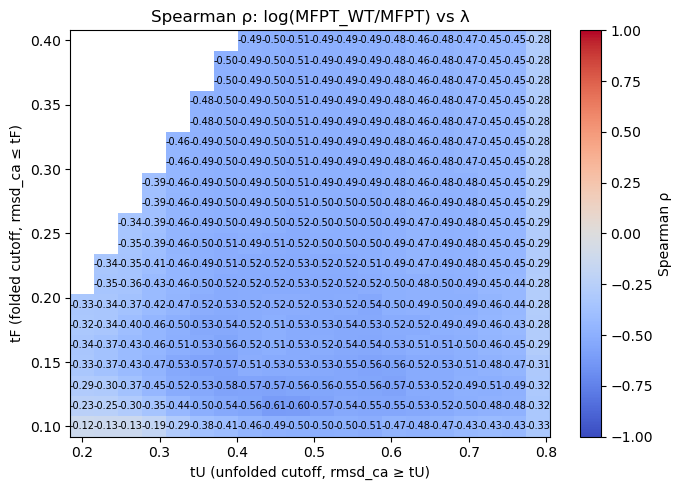

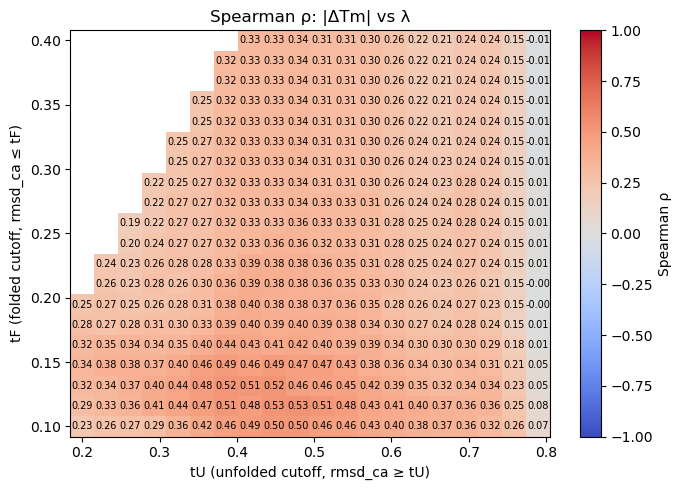

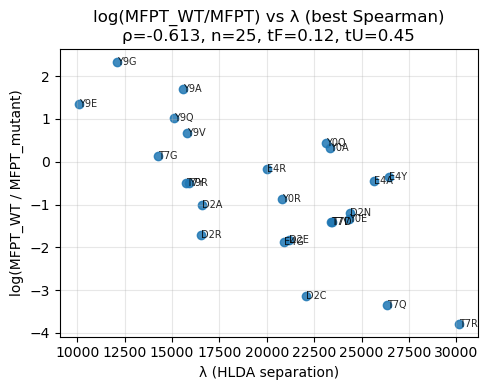

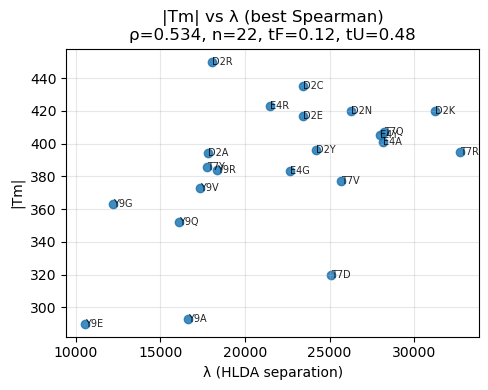

In [16]:
# ---- Load MFPT (log ratio vs WT) and |ΔTm| vs WT ----
mfpt = pd.read_csv(mfpt_csv)
mfpt["Mutant"] = mfpt["Mutant"].str.strip().replace(wildtype_alias)
mfpt["MFPT"] = pd.to_numeric(mfpt["MFPT"], errors="coerce")
mfpt_wt = mfpt.loc[mfpt["Mutant"] == "WT", "MFPT"].iloc[0]
mfpt["L_MFPT"] = np.log(mfpt_wt / mfpt["MFPT"])

tm_csv = Path("../data/Tm.csv")
tm = pd.read_csv(tm_csv)
tm["Mutant"] = tm["Mutant"].str.strip().replace(wildtype_alias)
tm["Tm"] = pd.to_numeric(tm["Tm"], errors="coerce")
tm_wt = tm.loc[tm["Mutant"] == "WT", "Tm"].iloc[0]
tm["Tm_abs"] = (tm["Tm"]).abs()

merged_all = (
    lambda_df
    .merge(mfpt[["Mutant","L_MFPT"]], on="Mutant", how="left")
    .merge(tm[["Mutant","Tm_abs"]], on="Mutant", how="left")
)

grid = merged_all[merged_all["filter"]=="grid"].copy()

# ---- Grid Spearman for each target (exclude missing per-target) ----
corrs_mfpt = (
    grid.dropna(subset=["lambda","L_MFPT"])
        .groupby(["tF","tU"])
        .apply(lambda g: pd.Series({
            "rho_mfpt": g["lambda"].corr(g["L_MFPT"], method="spearman"),
            "n_mfpt": len(g)
        }))
        .reset_index()
)

corrs_tm = (
    grid.dropna(subset=["lambda","Tm_abs"])
        .groupby(["tF","tU"])
        .apply(lambda g: pd.Series({
            "rho_tm": g["lambda"].corr(g["Tm_abs"], method="spearman"),
            "n_tm": len(g)
        }))
        .reset_index()
)

# join and compute a combined score to find the best-for-both point (optional)
corrs_both = corrs_mfpt.merge(corrs_tm, on=["tF","tU"], how="inner")
corrs_both["score_both"] = corrs_both["rho_mfpt"].abs() + corrs_both["rho_tm"].abs()
best_row = corrs_both.loc[corrs_both["score_both"].idxmax()]
best_tF, best_tU = float(best_row["tF"]), float(best_row["tU"])
print("\n[best-both] thresholds:")
print(f"tF={best_tF:.3f}, tU={best_tU:.3f}, ρ_mfpt={best_row['rho_mfpt']:.3f}, ρ_|ΔTm|={best_row['rho_tm']:.3f}, score={best_row['score_both']:.3f}")

def edges_from_centers(c):
    c = np.asarray(c, float)
    d = np.diff(c)
    if len(d) == 0:
        # single value: make a tiny box
        return np.array([c[0]-0.5, c[0]+0.5])
    edges = np.empty(c.size + 1, float)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0]     = c[0] - d[0]/2
    edges[-1]    = c[-1] + d[-1]/2
    return edges

def plot_heatmap_with_labels(df, value_col, title):
    P = df.pivot(index="tF", columns="tU", values=value_col).sort_index(ascending=True)
    x_centers = P.columns.values.astype(float)
    y_centers = P.index.values.astype(float)
    x_edges = edges_from_centers(x_centers)
    y_edges = edges_from_centers(y_centers)

    fig, ax = plt.subplots(figsize=(7,5))
    im = ax.pcolormesh(x_edges, y_edges, P.values, vmin=-1, vmax=1, cmap="coolwarm", shading="flat")

    for i, tF in enumerate(y_centers):
        for j, tU in enumerate(x_centers):
            val = P.iloc[i, j]
            if np.isfinite(val):
                ax.text(tU, tF, f"{val:.2f}", ha="center", va="center", fontsize=7, color="black")

    fig.colorbar(im, ax=ax).set_label("Spearman ρ")
    ax.set_xlabel("tU (unfolded cutoff, rmsd_ca ≥ tU)")
    ax.set_ylabel("tF (folded cutoff, rmsd_ca ≤ tF)")
    ax.set_title(title, loc="center")
    plt.tight_layout()
    plt.show()

plot_heatmap_with_labels(corrs_mfpt.rename(columns={"rho_mfpt":"val"}), "val",
                         "Spearman ρ: log(MFPT_WT/MFPT) vs λ")
plot_heatmap_with_labels(corrs_tm.rename(columns={"rho_tm":"val"}), "val",
                         "Spearman ρ: |ΔTm| vs λ")

# ---- Best-by-target scatters (|Spearman| max) with labels ----
def best_spearman_point(corrs_df, rho_col):
    if corrs_df.empty or corrs_df[rho_col].dropna().empty:
        return None
    idx = corrs_df[rho_col].abs().idxmax()
    return corrs_df.loc[idx]

best_m = best_spearman_point(corrs_mfpt, "rho_mfpt")
best_t = best_spearman_point(corrs_tm,   "rho_tm")

def add_wt_point_for_thresholds(ax, lambda_df, tF, tU):
    # Find WT's λ at the SAME thresholds (tF, tU); use isclose for float safety
    wt_rows = lambda_df[
        (lambda_df["Mutant"] == "WT")
        & np.isclose(lambda_df["tF"], tF)
        & np.isclose(lambda_df["tU"], tU)
    ]

    x_wt = float(wt_rows["lambda"].iloc[0])
    ax.scatter([x_wt], [0.0], s=40, edgecolor="black", color="red", zorder=5)
    ax.text(x_wt, 0.0, "WT", ha="center", va="bottom", fontsize=8, color="red", weight="bold")


def scatter_with_labels(df, x_col, y_col, label_col, title, xlab, ylab, rho, tF, tU):
    fig, ax = plt.subplots(figsize=(5,4))
    ax.scatter(df[x_col], df[y_col], alpha=0.85)
    for _, row in df.iterrows():
        ax.text(row[x_col], row[y_col], row[label_col],
                fontsize=7, ha="left", va="center", alpha=0.85)

    # add_wt_point_for_thresholds(ax, lambda_df, tF, tU)

    ax.set_title(f"{title}\nρ={rho:.3f}, n={len(df)}, tF={tF:.2f}, tU={tU:.2f}")
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- Scatter for log(MFPT_WT/MFPT) at its best (tF, tU)
if best_m is not None:
    tF_m, tU_m = float(best_m["tF"]), float(best_m["tU"])
    sub_m = grid.query("tF == @tF_m and tU == @tU_m")[["Mutant","lambda","L_MFPT"]].dropna()
    rho_m = sub_m["lambda"].corr(sub_m["L_MFPT"], method="spearman")
    scatter_with_labels(
        sub_m, "lambda", "L_MFPT", "Mutant",
        title="log(MFPT_WT/MFPT) vs λ (best Spearman)",
        xlab="λ (HLDA separation)",
        ylab="log(MFPT_WT / MFPT_mutant)",
        rho=rho_m, tF=tF_m, tU=tU_m
    )
else:
    print("[warn] No valid grid cells for MFPT (after missing-data exclusion).")

# --- Scatter for |ΔTm| at its best (tF, tU)
if best_t is not None:
    tF_t, tU_t = float(best_t["tF"]), float(best_t["tU"])
    sub_t = grid.query("tF == @tF_t and tU == @tU_t")[["Mutant","lambda","Tm_abs"]].dropna()
    rho_t = sub_t["lambda"].corr(sub_t["Tm_abs"], method="spearman")
    scatter_with_labels(
        sub_t, "lambda", "Tm_abs", "Mutant",
        title="|Tm| vs λ (best Spearman)",
        xlab="λ (HLDA separation)",
        ylab="|Tm|",
        rho=rho_t, tF=tF_t, tU=tU_t
    )
else:
    print("[warn] No valid grid cells for |ΔTm| (after missing-data exclusion).")


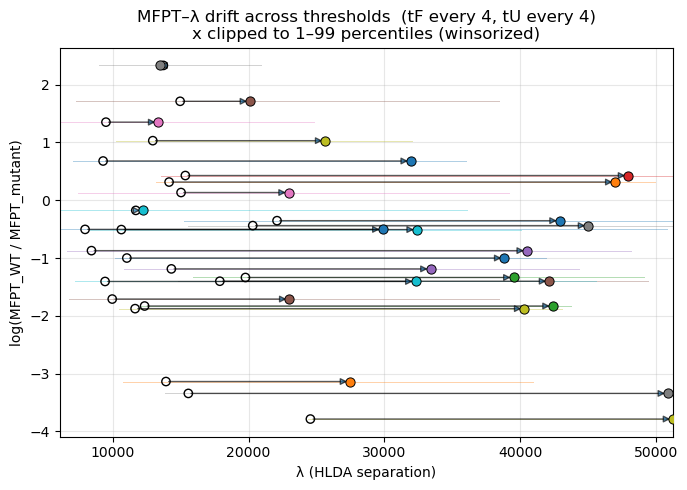

[warn] No valid threshold pairs after subsampling.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def scatter_mfpt_lambda_drift(
    grid_df,
    step_tF=4,
    step_tU=4,
    x_clip_pct=(1, 99),
    winsorize_x=True,
    mutant_subset=None,
    highlight_wt=True,
):
    """
    MFPT–λ drift across thresholds.
      - Subsample thresholds: every step_tF, step_tU
      - Only λ (x-axis) is clipped by percentiles; y is untouched
      - Draws a horizontal arrow from first -> last position per mutant
      - Marks starts (open) and ends (filled). WT highlighted if present.

    grid_df needs: ['Mutant','lambda','L_MFPT','tF','tU']
    """

    df = grid_df.copy()
    if mutant_subset is not None:
        df = df[df["Mutant"].isin(mutant_subset)]

    # Subsample thresholds on each axis
    tF_vals = np.sort(df["tF"].unique())
    tU_vals = np.sort(df["tU"].unique())
    tF_sub = tF_vals[::max(1, step_tF)]
    tU_sub = tU_vals[::max(1, step_tU)]

    # Build ordered (tF,tU) pairs with non-overlap constraint tU>tF
    pairs = np.array([(a, b) for a in tF_sub for b in tU_sub if b > a])
    if pairs.size == 0:
        print("[warn] No valid threshold pairs after subsampling.")
        return
    pairs = pairs[np.lexsort((pairs[:,1], pairs[:,0]))]  # sort by tF then tU

    # Robust x limits from the subsample; do NOT touch y
    sub_for_limits = df[np.isin(df["tF"], tF_sub) & np.isin(df["tU"], tU_sub)]
    if sub_for_limits.empty:
        print("[warn] No data for chosen subsample.")
        return
    x_lo, x_hi = np.percentile(sub_for_limits["lambda"].dropna(), x_clip_pct)

    def clip_x(x):
        return np.clip(x, x_lo, x_hi) if winsorize_x else x

    fig, ax = plt.subplots(figsize=(7, 5))

    # For each mutant, collect positions across sampled pairs (keeps y constant)
    for mutant, g in df.groupby("Mutant"):
        # take only sampled threshold rows in sorted pair order
        g_pairs = []
        for (tF_k, tU_k) in pairs:
            sel = g[np.isclose(g["tF"], tF_k) & np.isclose(g["tU"], tU_k)]
            if not sel.empty:
                r = sel.iloc[0]
                g_pairs.append((float(r["lambda"]), float(r["L_MFPT"])))
        if len(g_pairs) < 1:
            continue

        xs = np.array([p[0] for p in g_pairs], dtype=float)
        ys = np.array([p[1] for p in g_pairs], dtype=float)  # constant per mutant
        xs_c = clip_x(xs)

        # Draw thin path (optional; helpful if many sampled points)
        ax.plot(xs_c, ys, lw=0.6, alpha=0.35)

        # Start & end markers + direction arrow
        x_start, y_start = xs_c[0], ys[0]
        x_end,   y_end   = xs_c[-1], ys[-1]

        # Arrow shows direction start -> end
        ax.annotate(
            "", xy=(x_end, y_end), xytext=(x_start, y_start),
            arrowprops=dict(arrowstyle="-|>", lw=1.0, alpha=0.65)
        )
        # Start marker (open circle), End marker (filled)
        ax.scatter([x_start], [y_start], s=36, facecolors="none", edgecolors="black", zorder=4)
        ax.scatter([x_end],   [y_end],   s=44, edgecolors="black", linewidths=0.7, zorder=5)

        # Highlight WT path
        if highlight_wt and mutant == "WT":
            ax.plot(xs_c, ys, lw=1.6, alpha=0.9, color="red", zorder=5, label="WT path")
            ax.scatter([x_start], [y_start], s=48, facecolors="none", edgecolors="red", linewidths=1.2, zorder=6)
            ax.scatter([x_end],   [y_end],   s=56, color="red", edgecolors="black", linewidths=0.8, zorder=7)
            ax.text(x_end, y_end, " WT", fontsize=8, va="center", ha="left", color="red", zorder=8)

    # Axes: clip only x; y untouched
    ax.set_xlim(x_lo, x_hi)
    ax.set_xlabel("λ (HLDA separation)")
    ax.set_ylabel("log(MFPT_WT / MFPT_mutant)")
    ax.set_title(
        f"MFPT–λ drift across thresholds  (tF every {step_tF}, tU every {step_tU})\n"
        f"x clipped to {x_clip_pct[0]}–{x_clip_pct[1]} percentiles"
        + (" (winsorized)" if winsorize_x else "")
    )
    ax.grid(alpha=0.3)
    if highlight_wt and "WT" in df["Mutant"].unique():
        ax.legend(fontsize=8, loc="best")
    plt.tight_layout()
    plt.show()


# Basic
scatter_mfpt_lambda_drift(grid, step_tF=4, step_tU=4)

# Focus on a few mutants (cleaner)
scatter_mfpt_lambda_drift(grid, step_tF=4, step_tU=4, mutant_subset=["L9A","Y9F"])
